# 03 — Regimes estendidos: onde o RL poderia ganhar

Estabelecido que o controle clássico domina na formulação original, resta a
pergunta: **existe alguma extensão do problema em que o RL leve vantagem?**

Três regimes foram construídos e avaliados. Os três falharam, por razões
estruturalmente distintas — e a análise dessas razões é o resultado mais útil
deste notebook.

In [1]:
%matplotlib inline
import sys, warnings
sys.path.insert(0, '/home/renan/Downloads/air_conditioning_classroom/v5')
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hvac import results as R
from hvac import figures as F

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
F.aplicar_estilo()

## 3.1 Rastreamento de precisão

Um laboratório com tolerância de ±0,5 °C em torno do setpoint, equipamento
reversível (aquece e resfria), ação contínua e observação enriquecida com erro
escalado pela tolerância, integral com fuga e derivada. Agentes TD3 e SAC
treinados sob três perfis de custo.

In [2]:
lab = R.laboratorio_precisao()
lab.round(3)

,controlador,na_tol_%,sigma,|T-24|,desv_max,custo_dia,custo_ponta,kWh_dia,ajustes_h
0,PI bidirecional,100.000,0.088,0.069,0.315,14.759,4.732,17.170,0.556
1,TD3 Lab_Equilibrado,100.000,0.198,0.163,0.465,16.436,5.418,19.255,2.236
2,TD3 Lab_Precisao,97.333,0.186,0.138,0.642,18.143,5.241,21.372,1.208
3,SAC Lab_Precisao,94.222,0.268,0.229,0.607,16.402,5.583,18.792,1.861
4,SAC Lab_Equilibrado,92.000,0.225,0.230,0.766,16.897,4.472,20.176,2.306
5,TD3 Lab_Economico,86.667,0.293,0.222,0.682,15.498,4.228,18.590,1.694
6,Antecipatório (manual),80.000,0.222,0.282,0.635,15.393,4.972,17.705,1.542


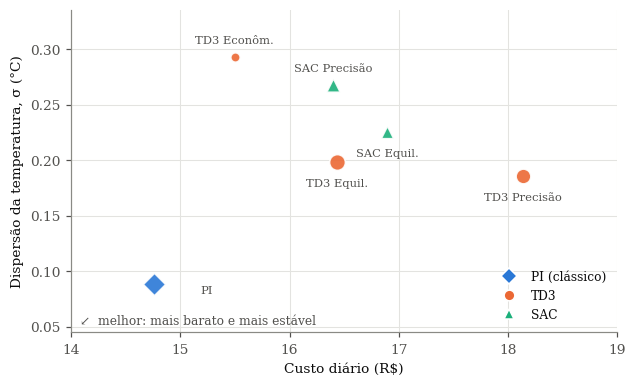

In [3]:
fig = F.fig_precisao(lab)
plt.close(fig)
fig

### Leitura

O **PI bidirecional permanece superior**: 100 % do tempo dentro da tolerância com
σ = 0,088 °C e R$ 14,76/dia, contra σ = 0,198 °C e R$ 16,44/dia do melhor TD3.
Ele ocupa sozinho o canto ótimo — mais barato *e* mais estável.

Tornar o problema **mais difícil** não mudou a **classe** do problema. Um problema
de rastreamento difícil continua sendo rastreamento, e responde a uma sintonia
mais agressiva do controlador clássico.

## 3.2 Antecipação tarifária

Sob tarifa branca real (razão de ponta 2,21×), a oportunidade de pré-resfriamento
é limitada pela própria tolerância: com ±0,5 °C, o armazenamento térmico
disponível cobre apenas ~29 % da duração do posto de ponta. A margem para
antecipação é estruturalmente pequena — o "reservatório" é raso demais.

## 3.3 Demanda contratada — e uma auditoria do próprio experimento

A hipótese mais promissora: uma restrição sobre o **máximo** da média integrada em
15 min, e não sobre a média. Um PI minimiza erro instantâneo e não tem como
representar "não ultrapasse X kW em nenhum momento"; respeitá-la exigiria
**antecipar** carga.

Uma versão preliminar fixava a demanda contratada em **0,70 kW**, valor escolhido
por varredura como "ponto de máxima tensão" entre conforto e restrição. Aplicando
a esse valor a mesma exigência que este trabalho aplica ao manuscrito auditado,
constatou-se que ele era **infactível**.

In [4]:
dem = R.dimensionamento_demanda()
print(dem["sizing"].as_table())

Dimensionamento da demanda contratada (condição de projeto)
--------------------------------------------------------------
  externa de projeto             36.00 °C
  ocupação de projeto               45 pessoas
  setpoint mantido               24.00 °C

  carga: pessoas                 13.50 u
  carga: envelope                 6.00 u
  carga: TOTAL sustentada        19.50 u
  fração da capacidade          0.4875

  potência de REGIME            1.2037 kW
  margem de contratação          10.0%
  DEMANDA CONTRATADA            1.3241 kW

  contrafactuais (a estrutura do problema, não uma escolha):
    pulldown a plena carga      2.9307 kW   (2.21x o contrato)
    aquecimento pleno           2.1980 kW


O regime permanente de pior caso — 45 ocupantes, externa a 36 °C, mantendo o
setpoint — exige **1,204 kW**. Um contrato de 0,70 kW está **72 % abaixo** disso e
sustenta apenas ~17 dos 45 ocupantes. **Nenhuma política respeita tal restrição**,
porque antecipar não cria regime permanente: pré-resfriar compra um transitório
limitado pela tolerância, não potência contínua.

O valor foi substituído por dimensionamento **derivado da condição de projeto**
(regime de pior caso + margem de contratação de 10 %), resultando em 1,324 kW.

In [5]:
dem["comparacao"].round(3)

,contrato,controlador,tolerancia_pct,pico_max_kw,excedente_kw,cenarios_violando,n_cenarios
0,"0,70 kW (varredura)",PI ingênuo,100.0,1.213,0.513,7,9
1,"0,70 kW (varredura)",PI ciente da demanda,100.0,0.698,0.000,0,9
2,1.324 kW (derivado),PI ingênuo,100.0,1.213,0.000,0,9
3,1.324 kW (derivado),PI ciente da demanda,100.0,1.213,0.000,0,9


### Leitura — a hipótese perde sua base

Sob o contrato **arbitrado** (0,70 kW), o PI ingênuo viola em 7 de 9 cenários e o
PI ciente da restrição não viola: parecia haver um dilema real.

Sob o contrato **derivado** (1,324 kW), **nenhum** dos nove cenários excede o
limite, e os dois PIs tornam-se indistinguíveis. Não há o que antecipar.

O "dilema" era artefato de uma restrição impossível, e não evidência de que
antecipação fosse necessária.

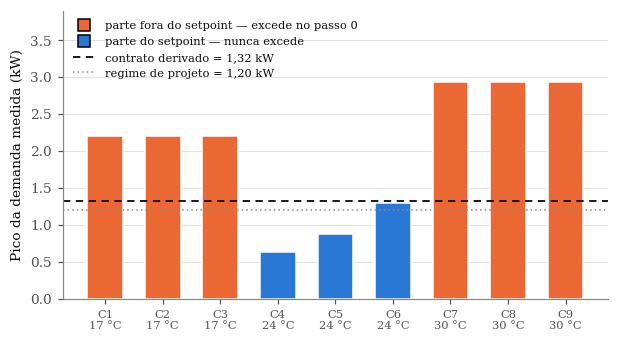

In [6]:
fig = F.fig_demanda(dem)
plt.close(fig)
fig

In [7]:
dem["origem_da_pressao"]

,cenario,temp_inicial,pico_kw,excede
0,C1,17.0,2.198033,True
1,C2,17.0,2.198033,True
2,C3,17.0,2.198033,True
3,C4,24.0,0.630138,False
4,C5,24.0,0.881805,False
5,C6,24.0,1.299647,False
6,C7,30.0,2.930710,True
7,C8,30.0,2.930710,True
8,C9,30.0,2.930710,True


### Leitura — a contradição estrutural

Os únicos cenários que excedem o contrato derivado são os que **partem fora do
setpoint** (17 °C exige aquecimento pleno, 2,198 kW; 30 °C exige pulldown,
2,931 kW). Neles a violação ocorre no **passo inicial** — instante em que
antecipação é impossível por definição, pois não há como pré-resfriar antes de
t = 0.

Ao construir a matriz de cenários partindo do setpoint — decisão correta, tomada
justamente para eliminar essa violação impossível —, elimina-se **simultaneamente
a única fonte de demanda acima do regime permanente**.

**O conjunto no qual a hipótese pode ser testada é vazio.**

## 3.4 Síntese: por que as três tentativas falharam

| Tentativa | Resultado | Razão |
|---|---|---|
| Precisão (±0,5 °C) | PI vence: σ 0,088 vs 0,198 | rastreamento mais apertado ainda é rastreamento |
| Antecipação tarifária | oportunidade ~29 % da ponta | tolerância limita o armazenamento térmico |
| Demanda contratada | conjunto de teste vazio | pressão só existe onde antecipar é impossível |

As três introduziram **dificuldade**, não **estrutura**. Tornar o problema mais
difícil não muda a classe a que ele pertence.

### A limitação de método que fecha o argumento

O nicho do RL é o **descasamento de modelo** — situações em que o modelo é
desconhecido, impreciso ou variável. Num simulador de autoria própria, o modelo é
**exato por construção**.

Qualquer comparação conduzida integralmente dentro do próprio ambiente favorece
estruturalmente os métodos que exploram o modelo, incluindo controle preditivo.
**Este ambiente não pode, em princípio, exibir o regime em que o RL tem
vantagem.** Não é limitação da implementação; é limitação do método de
investigação.

Testar a hipótese de verdade exige transferência simulação-realidade ou benchmark
de terceiros — BOPTEST (Boutahri e Tilioua, 2025) ou BuildingGym (Dai et al.,
2025).